Adding Business Licenses + POI Features
Creating dist_to_loop_km and is_airport...
Loading saved Business Licenses file...
Loaded 1,027,523 active business licenses
Creating POI categories...

Final Model Performance with POI + Business Data:
R² Score: 0.666
MAE: 50,806 trips

Feature Importance:
                 feature  importance
7             num_hotels    0.487113
3             is_airport    0.217276
2        dist_to_loop_km    0.082658
6               num_bars    0.061831
5        num_restaurants    0.055496
4  num_business_licenses    0.034576
0     population_density    0.032072
8             num_retail    0.015170
1    avg_satellite_proxy    0.013808


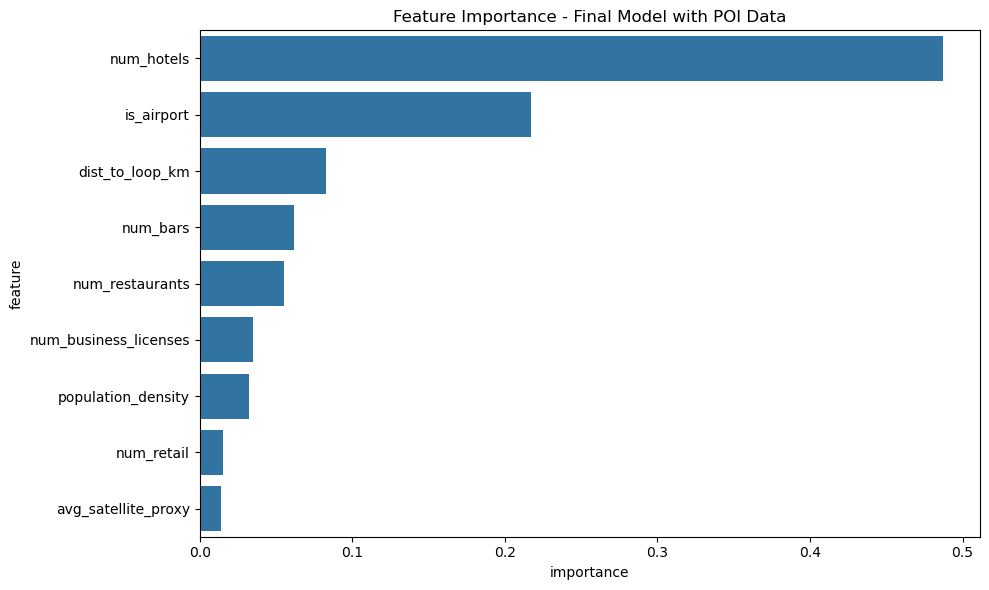

In [1]:
# Adding Business Licenses + POI Features

import geopandas as gpd
import pandas as pd
import numpy as np
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import r2_score, mean_absolute_error
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from shapely.geometry import Point
import os

print("Adding Business Licenses + POI Features")

# PATHS
comm_areas_path = 'chicago_community_areas_with_hotspots.geojson'
business_csv_path = 'chicago_business_licenses.csv'   


# Load community areas
comm_areas = gpd.read_file(comm_areas_path)

# Ensure essential spatial features exist (dist_to_loop + is_airport)
if 'dist_to_loop_km' not in comm_areas.columns:
    print("Creating dist_to_loop_km and is_airport...")
    comm_areas_metric = comm_areas.to_crs(epsg=3435)
    loop_point = gpd.GeoSeries([Point(-87.6298, 41.8781)], crs="EPSG:4326").to_crs(epsg=3435).iloc[0]
    comm_areas['dist_to_loop_km'] = comm_areas_metric.geometry.distance(loop_point) / 1000
    
    comm_areas['is_airport'] = 0
    comm_areas.loc[comm_areas['community'].str.contains('OHARE|MIDWAY', case=False, na=False), 'is_airport'] = 1

# Load or download Business Licenses
if os.path.exists(business_csv_path):
    print("Loading saved Business Licenses file...")
    business = pd.read_csv(business_csv_path, low_memory=False)
else:
    print("Downloading Business Licenses (this will take a minute)...")
    business_url = "https://data.cityofchicago.org/api/views/xqx5-8hwx/rows.csv?accessType=DOWNLOAD"
    business = pd.read_csv(business_url, low_memory=False)
    business.to_csv(business_csv_path, index=False)
    print(f"Business licenses saved locally as '{business_csv_path}'")

# Filter active licenses
business = business[business['LICENSE STATUS'] == 'AAI']

# Create GeoDataFrame
business_gdf = gpd.GeoDataFrame(
    business,
    geometry=gpd.points_from_xy(business['LONGITUDE'], business['LATITUDE']),
    crs="EPSG:4326"
).dropna(subset=['LONGITUDE', 'LATITUDE'])

print(f"Loaded {len(business_gdf):,} active business licenses")

# Spatial join to community areas
business_with_area = gpd.sjoin(business_gdf, comm_areas[['pickup_community_area', 'geometry']], how='left', predicate='within')

# Total business licenses per area
biz_count = business_with_area.groupby('pickup_community_area').size().reset_index(name='num_business_licenses')
comm_areas = comm_areas.merge(biz_count, on='pickup_community_area', how='left')
comm_areas['num_business_licenses'] = comm_areas['num_business_licenses'].fillna(0)

# Specific POI categories
print("Creating POI categories...")
categories = {
    'restaurants': ['Restaurant', 'Eating', 'Food'],
    'bars': ['Tavern', 'Bar', 'Liquor'],
    'hotels': ['Hotel', 'Motel'],
    'retail': ['Retail', 'Store', 'Shop']
}

for cat, keywords in categories.items():
    mask = business_gdf['BUSINESS ACTIVITY'].str.contains('|'.join(keywords), case=False, na=False)
    cat_gdf = business_gdf[mask].copy()
    if len(cat_gdf) > 0:
        cat_with_area = gpd.sjoin(cat_gdf, comm_areas[['pickup_community_area', 'geometry']], how='left', predicate='within')
        count = cat_with_area.groupby('pickup_community_area').size().reset_index(name=f'num_{cat}')
        comm_areas = comm_areas.merge(count, on='pickup_community_area', how='left')
        comm_areas[f'num_{cat}'] = comm_areas[f'num_{cat}'].fillna(0)



# FINAL MODEL
features = [
    'population_density', 'avg_satellite_proxy', 'dist_to_loop_km', 
    'is_airport', 'num_business_licenses', 'num_restaurants', 
    'num_bars', 'num_hotels', 'num_retail'
]

target = 'total_trips'

df = comm_areas[features + [target]].copy().fillna(0)

cap = df[target].quantile(0.95)
df['target_capped'] = df[target].clip(upper=cap)

X = df[features]
y = df['target_capped']

# LOOCV
loo = LeaveOneOut()
y_true, y_pred = [], []

for train_idx, test_idx in loo.split(X):
    model = xgb.XGBRegressor(n_estimators=400, learning_rate=0.03, max_depth=6, 
                             subsample=0.85, colsample_bytree=0.8, random_state=42)
    model.fit(X.iloc[train_idx], y.iloc[train_idx])
    pred = model.predict(X.iloc[test_idx])[0]
    y_true.append(y.iloc[test_idx].values[0])
    y_pred.append(pred)

r2 = r2_score(y_true, y_pred)
mae = mean_absolute_error(y_true, y_pred)

print(f"\nFinal Model Performance with POI + Business Data:")
print(f"R² Score: {r2:.3f}")
print(f"MAE: {mae:,.0f} trips")

# Feature Importance
final_model = xgb.XGBRegressor(**model.get_params())
final_model.fit(X, y)
importance = pd.DataFrame({
    'feature': features,
    'importance': final_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nFeature Importance:")
print(importance)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance)
plt.title("Feature Importance - Final Model with POI Data")
plt.tight_layout()
plt.show()

Residual Analysis - Rebuilding Features First
Rebuilding POI features...


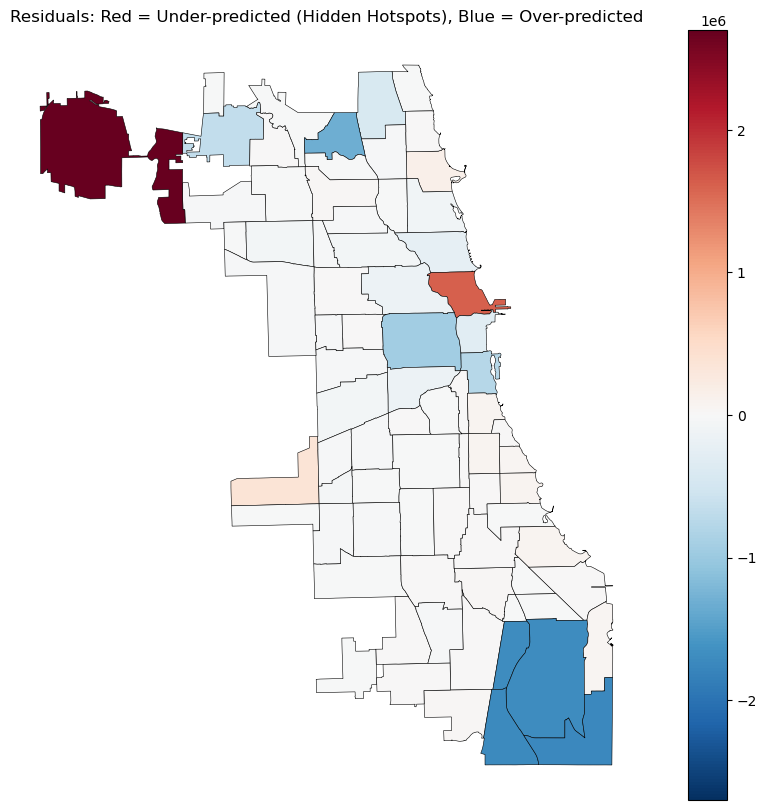


Top 5 Under-predicted (Hidden Hotspots - model misses real demand):
          community  total_trips  predicted_trips      residual
75            OHARE      2817761     1.179126e+05  2.699848e+06
7   NEAR NORTH SIDE      3079577     1.459742e+06  1.619835e+06
55   GARFIELD RIDGE       414304     4.655256e+04  3.677514e+05
2            UPTOWN       230533     7.360915e+04  1.569239e+05
34          DOUGLAS        96479     1.352952e+04  8.294948e+04

Top 5 Over-predicted (model expects more trips than reality):
        community  total_trips  predicted_trips     residual
54      HEGEWISCH        10067      1741400.125 -1731333.125
53      RIVERDALE        13646      1740740.875 -1727094.875
50  SOUTH DEERING        21340      1721191.375 -1699851.375
49        PULLMAN        21362      1719945.125 -1698583.125
12     NORTH PARK        18516      1326327.750 -1307811.750

Residual analysis completed and saved.


In [2]:
# Residual Analysis

import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import cross_val_predict
from xgboost import XGBRegressor
from shapely.geometry import Point

print("Residual Analysis - Rebuilding Features First")

# PATHS
comm_base_path = 'chicago_community_areas_with_hotspots.geojson'
business_csv_path = 'chicago_business_licenses.csv'


# Load base community areas
comm_areas = gpd.read_file(comm_base_path)

# Rebuild spatial features
comm_areas_metric = comm_areas.to_crs(epsg=3435)
loop_point = gpd.GeoSeries([Point(-87.6298, 41.8781)], crs="EPSG:4326").to_crs(epsg=3435).iloc[0]
comm_areas['dist_to_loop_km'] = comm_areas_metric.geometry.distance(loop_point) / 1000

comm_areas['is_airport'] = 0
comm_areas.loc[comm_areas['community'].str.contains('OHARE|MIDWAY', case=False, na=False), 'is_airport'] = 1

# Rebuild POI features (Business Licenses and Categories)
print("Rebuilding POI features...")

if not os.path.exists(business_csv_path):
    print("Downloading Business Licenses...")
    url = "https://data.cityofchicago.org/api/views/xqx5-8hwx/rows.csv?accessType=DOWNLOAD"
    business = pd.read_csv(url, low_memory=False)
    business.to_csv(business_csv_path, index=False)
else:
    business = pd.read_csv(business_csv_path, low_memory=False)

business = business[business['LICENSE STATUS'] == 'AAI']

business_gdf = gpd.GeoDataFrame(
    business,
    geometry=gpd.points_from_xy(business['LONGITUDE'], business['LATITUDE']),
    crs="EPSG:4326"
).dropna(subset=['LONGITUDE', 'LATITUDE'])

# Spatial join
business_with_area = gpd.sjoin(business_gdf, comm_areas[['pickup_community_area', 'geometry']], how='left', predicate='within')

# Total businesses
biz_count = business_with_area.groupby('pickup_community_area').size().reset_index(name='num_business_licenses')
comm_areas = comm_areas.merge(biz_count, on='pickup_community_area', how='left')

# Specific POI
poi_map = {
    'num_restaurants': ['Restaurant', 'Eating', 'Food'],
    'num_bars': ['Tavern', 'Bar', 'Liquor'],
    'num_hotels': ['Hotel', 'Motel'],
    'num_retail': ['Retail', 'Store', 'Shop']
}

for col, keywords in poi_map.items():
    mask = business_gdf['BUSINESS ACTIVITY'].str.contains('|'.join(keywords), case=False, na=False)
    cat_gdf = business_gdf[mask].copy()
    if len(cat_gdf) > 0:
        cat_with_area = gpd.sjoin(cat_gdf, comm_areas[['pickup_community_area', 'geometry']], how='left', predicate='within')
        count = cat_with_area.groupby('pickup_community_area').size().reset_index(name=col)
        comm_areas = comm_areas.merge(count, on='pickup_community_area', how='left')

comm_areas = comm_areas.fillna(0)

# Add interaction term
comm_areas['hotel_airport_interaction'] = comm_areas['num_hotels'] * comm_areas['is_airport']

# Features for modeling
features = [
    'population_density', 'avg_satellite_proxy', 'dist_to_loop_km', 
    'is_airport', 'num_business_licenses', 'num_hotels', 
    'num_restaurants', 'num_bars', 'num_retail', 'hotel_airport_interaction'
]

target = 'total_trips'

X = comm_areas[features].fillna(0)
y = comm_areas[target]

# Cross-validated predictions
model = XGBRegressor(n_estimators=400, learning_rate=0.03, max_depth=6, 
                     subsample=0.85, colsample_bytree=0.8, random_state=42)

y_pred = cross_val_predict(model, X, y, cv=5)

comm_areas['predicted_trips'] = y_pred
comm_areas['residual'] = comm_areas[target] - y_pred
comm_areas['residual_pct'] = (comm_areas['residual'] / comm_areas[target].replace(0, np.nan)) * 100

# Residual Map
fig, ax = plt.subplots(figsize=(12, 10))
comm_areas.plot(column='residual', cmap='RdBu_r', legend=True, ax=ax,
                edgecolor='black', linewidth=0.4,
                vmin=-comm_areas['residual'].abs().max(),
                vmax=comm_areas['residual'].abs().max())
ax.set_title("Residuals: Red = Under-predicted (Hidden Hotspots), Blue = Over-predicted")
plt.axis('off')
plt.show()

# Top areas
print("\nTop 5 Under-predicted (Hidden Hotspots - model misses real demand):")
print(comm_areas.nlargest(5, 'residual')[['community', 'total_trips', 'predicted_trips', 'residual']])

print("\nTop 5 Over-predicted (model expects more trips than reality):")
print(comm_areas.nsmallest(5, 'residual')[['community', 'total_trips', 'predicted_trips', 'residual']])

# Save
comm_areas.to_file('chicago_community_areas_with_residuals.geojson', driver='GeoJSON')
print("\nResidual analysis completed and saved.")